## Cell 0 — Mount Drive & Install Packages

In [2]:
# ── Mount Google Drive ─────────────────────────────────────
from google.colab import drive, auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io, os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

# ── Verify dataset ─────────────────────────────────────────
FEATHER_PATH = '/content/drive/MyDrive/CapStone/classification_columns.feather'

if not os.path.isfile(FEATHER_PATH):
    print("File not found — re-downloading via Drive API...")
    auth.authenticate_user()
    service  = build('drive', 'v3')
    FILE_ID  = '1KUF8DM39BIa_Fpi879hteXnzqyLwxzpJ'
    request  = service.files().get_media(fileId=FILE_ID)
    fh       = io.FileIO(FEATHER_PATH, mode='wb')
    dl       = MediaIoBaseDownload(fh, request, chunksize=50*1024*1024)
    done     = False
    while not done:
        status, done = dl.next_chunk()
        print(f"  {int(status.progress()*100)}%...")
    fh.close()

print(f"✓ Dataset: {os.path.getsize(FEATHER_PATH)/1e6:.1f} MB — ready")

Mounted at /content/drive
✓ Dataset: 825.8 MB — ready


In [3]:
!pip install -q catboost lightgbm xgboost scikit-learn \
    pyarrow pytorch-forecasting lightning tqdm
print("✓ All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 32.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 79.3 MB/s eta 0:00:00
✓ All packages installed


## Cell 1 — Imports & Constants

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, roc_auc_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Device ─────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ══════════════════════════════════════════════════════════
# NOTEBOOK IDENTITY — change these per notebook only
# ══════════════════════════════════════════════════════════
STORM_YEAR           = 1996
PEAK_DATE            = pd.Timestamp('1996-10-23')
TRACK_B_MONTHS       = [9, 10, 11]   # Sep–Nov
STORM_MONTHS_EXCLUDE = []              # # no storm in Sep–Nov 1996
# ══════════════════════════════════════════════════════════

FORECAST_HORIZON = 60    # minutes ahead
SEQ_LEN          = 180   # LSTM lookback (3 hours)
BATCH_SIZE       = 256
N_SPLITS         = 5

TARGET_REG = 'dBHt_forecast'
TARGET_CLF = '90_cross_forecast'

BASE_DIR     = '/content/drive/MyDrive/CapStone'
FEATHER_PATH = os.path.join(BASE_DIR, 'classification_columns.feather')
MODEL_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
DATA_DIR     = os.path.join(BASE_DIR, 'data', 'processed')

RAW_FEATURES = [
    'BX_GSE', 'BY_GSM', 'BZ_GSM',
    'flow_speed', 'proton_density', 'Pressure',
    'SYM_H', 'AE_INDEX', 'sinMLT', 'cosMLT',
]
LAG_FEATURES      = ['dBHt_t1', 'dBHt_t2']
ROLLING_FEATURES  = [
    'dBHt_roll_mean_30', 'dBHt_roll_std_30',
    'BZ_GSM_roll_mean_30', 'BZ_GSM_roll_std_30',
    'SYM_H_roll_mean_30', 'SYM_H_roll_std_30',
    'AE_INDEX_roll_mean_30', 'AE_INDEX_roll_std_30',
]
GRADIENT_FEATURES = [
    'BZ_GSM_grad', 'SYM_H_grad',
    'flow_speed_grad', 'Pressure_grad',
]
ALL_FEATURES = RAW_FEATURES + LAG_FEATURES + ROLLING_FEATURES + GRADIENT_FEATURES

# ── Create all output directories ──────────────────────────
for d in [
    os.path.join(MODEL_DIR, 'ml'),
    os.path.join(MODEL_DIR, 'dl'),
    os.path.join(RESULTS_DIR, 'track_a'),
    os.path.join(RESULTS_DIR, 'track_b'),
    os.path.join(RESULTS_DIR, 'figures'),
    os.path.join(RESULTS_DIR, 'shift'),
    os.path.join(DATA_DIR, 'storm_windows'),
    os.path.join(DATA_DIR, 'quiet_windows'),
]:
    os.makedirs(d, exist_ok=True)

print(f"Device           : {DEVICE}")
print(f"Notebook         : {STORM_YEAR} — {PEAK_DATE.date()}")
print(f"Forecast horizon : {FORECAST_HORIZON} min ahead")
print(f"Sequence length  : {SEQ_LEN} min lookback")
print(f"Track B months   : {TRACK_B_MONTHS}")
print(f"Features         : {len(ALL_FEATURES)}")
print(f"Targets          : {TARGET_REG}  |  {TARGET_CLF}")
print(f"\nDirectories confirmed:")
for d in ['models/ml', 'models/dl', 'results/track_a',
          'results/track_b', 'results/figures', 'results/shift']:
    full = os.path.join(BASE_DIR, d)
    print(f"  {'✓' if os.path.isdir(full) else '✗'}  {d}")

Device           : cuda
Notebook         : 1996 — 1996-10-23
Forecast horizon : 60 min ahead
Sequence length  : 180 min lookback
Track B months   : [9, 10, 11]
Features         : 24
Targets          : dBHt_forecast  |  90_cross_forecast

Directories confirmed:
  ✓  models/ml
  ✓  models/dl
  ✓  results/track_a
  ✓  results/track_b
  ✓  results/figures
  ✓  results/shift


In [5]:
print("Loading dataset...")
df = feather.read_feather(FEATHER_PATH)
df['Date_UTC'] = pd.to_datetime(df['Date_UTC'])
df = df.set_index('Date_UTC').sort_index()

df['dBHt_t1'] = df['dBHt'].shift(1)
df['dBHt_t2'] = df['dBHt'].shift(2)

for col in ['dBHt', 'BZ_GSM', 'SYM_H', 'AE_INDEX']:
    df[f'{col}_roll_mean_30'] = df[col].rolling(30, min_periods=1).mean()
    df[f'{col}_roll_std_30']  = df[col].rolling(30, min_periods=1).std().fillna(0)

for col in ['BZ_GSM', 'SYM_H', 'flow_speed', 'Pressure']:
    df[f'{col}_grad'] = df[col].diff().fillna(0)

df[TARGET_REG] = df['dBHt'].shift(-FORECAST_HORIZON)
df[TARGET_CLF] = (
    df['90_cross'].shift(-FORECAST_HORIZON).fillna(0).astype(int)
)
df = df.dropna(subset=['dBHt_t1', 'dBHt_t2', TARGET_REG])

df_year = df[df.index.year == STORM_YEAR].copy()

print(f"Full dataset : {df.shape[0]:,} rows")
print(f"\n── {STORM_YEAR} only ─────────────────────────────────────────")
print(f"  Rows         : {len(df_year):,}")
print(f"  Date range   : {df_year.index.min()} → "
      f"{df_year.index.max()}")
print(f"  Peak dBHt    : {df_year['dBHt'].max():.2f} nT/min")
print(f"  Peak date    : {df_year['dBHt'].idxmax().date()}")
print(f"  90_cross pos : "
      f"{df_year[TARGET_CLF].sum():,} rows "
      f"({df_year[TARGET_CLF].mean()*100:.3f}%)")
print(f"  Null check   : "
      f"{df_year[ALL_FEATURES+[TARGET_REG,TARGET_CLF]].isnull().sum().sum()} nulls")

Loading dataset...
Full dataset : 12,081,284 rows

── 1996 only ─────────────────────────────────────────
  Rows         : 526,749
  Date range   : 1996-01-01 00:00:00 → 1996-12-31 23:59:00
  Peak dBHt    : 86.05 nT/min
  Peak date    : 1996-10-23
  90_cross pos : 0 rows (0.000%)
  Null check   : 0 nulls


## Cell 2 — Load Dataset & Engineer Features

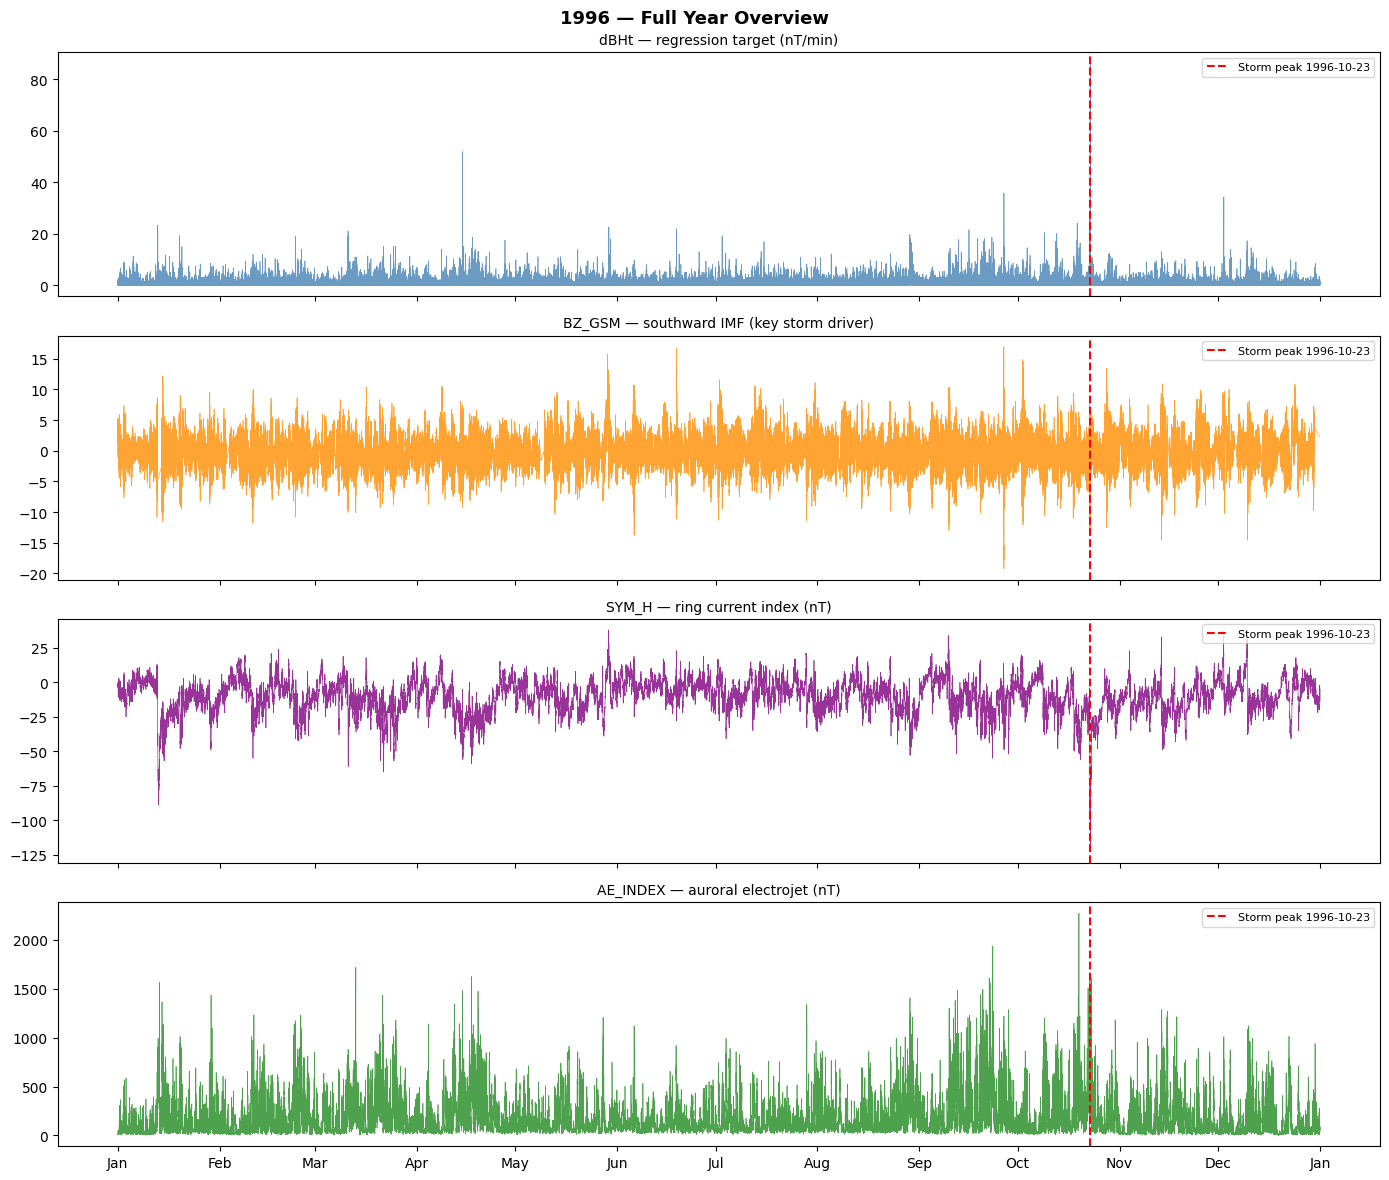

Saved: results/figures/eda_1996.png

── Feature statistics (1996) ─────────────────────
             dBHt      BZ_GSM       SYM_H    AE_INDEX  flow_speed    Pressure
count  526749.000  526749.000  526749.000  526749.000  526749.000  526749.000
mean        1.038      -0.190     -10.116     167.059     419.172       2.537
std         1.186       2.637      12.002     173.828      78.118       1.286
min         0.000     -19.230    -123.000       3.000     236.000       0.110
25%         0.100      -1.820     -17.000      50.000     360.900       1.710
50%         0.985      -0.270      -9.000     102.000     402.400       2.250
75%         1.389       1.380      -2.000     223.000     464.100       3.044
max        86.046      16.950      38.000    2273.000     746.400      29.280


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

plot_cfg = [
    ('dBHt',     'steelblue',   'dBHt — regression target (nT/min)'),
    ('BZ_GSM',   'darkorange',  'BZ_GSM — southward IMF (key storm driver)'),
    ('SYM_H',    'purple',      'SYM_H — ring current index (nT)'),
    ('AE_INDEX', 'forestgreen', 'AE_INDEX — auroral electrojet (nT)'),
]
for ax, (col, color, title) in zip(axes, plot_cfg):
    ax.plot(df_year.index, df_year[col],
            color=color, lw=0.5, alpha=0.8)
    ax.axvline(PEAK_DATE, color='red', ls='--',
               lw=1.5, label=f'Storm peak {PEAK_DATE.date()}')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.suptitle(f'{STORM_YEAR} — Full Year Overview',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR,'figures',f'eda_{STORM_YEAR}.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f"Saved: results/figures/eda_{STORM_YEAR}.png")

print(f"\n── Feature statistics ({STORM_YEAR}) ─────────────────────")
print(df_year[['dBHt','BZ_GSM','SYM_H',
               'AE_INDEX','flow_speed','Pressure']
              ].describe().round(3).to_string())

## Run Cell 4 — storm window extraction

In [7]:
search   = df_year.loc[
    PEAK_DATE - pd.Timedelta(days=3):
    PEAK_DATE + pd.Timedelta(days=3), TARGET_REG
]
PEAK_TS  = search.idxmax()
PEAK_VAL = search.max()

PRE_STORM_START = PEAK_TS - pd.Timedelta(hours=48)
QUIET_START     = PRE_STORM_START - pd.Timedelta(days=10)

pre_window  = df_year.loc[PRE_STORM_START:PEAK_TS, TARGET_REG]
onset_mask  = pre_window >= 10.0
STORM_ONSET = (onset_mask[onset_mask].index[0]
               if onset_mask.any() else PRE_STORM_START)

post_peak      = df_year.loc[PEAK_TS:, TARGET_REG]
above          = (post_peak >= 10.0).values
STORM_END      = None
SUSTAINED_MINS = 180
for i in range(len(above) - SUSTAINED_MINS):
    if not any(above[i : i + SUSTAINED_MINS]):
        STORM_END = post_peak.index[i]
        break
if STORM_END is None:
    STORM_END = PEAK_TS + pd.Timedelta(hours=48)
    print("Warning: used fallback storm end")

RECOVERY_END = STORM_END + pd.Timedelta(hours=48)

storm_window = df_year.loc[
    QUIET_START:RECOVERY_END,
    ALL_FEATURES + ['dBHt', TARGET_REG, TARGET_CLF]
].copy()

def label_phase(ts):
    if ts < PRE_STORM_START: return 'quiet'
    elif ts < STORM_ONSET:   return 'pre_storm'
    elif ts <= STORM_END:    return 'storm'
    else:                    return 'recovery'

storm_window['phase'] = storm_window.index.map(label_phase)

def assign_severity(val):
    if val < 10:    return 'none_storm'
    elif val < 100: return 'Minor'
    elif val < 250: return 'Moderate'
    elif val < 400: return 'Strong'
    else:           return 'Severe_Extreme'

storm_window['severity'] = storm_window[TARGET_REG].apply(
    assign_severity
)

STORM_PATH = os.path.join(
    DATA_DIR, 'storm_windows', f'{STORM_YEAR}_storm.csv'
)
storm_window.to_csv(STORM_PATH)

print(f"── Storm window boundaries ───────────────────────────")
print(f"  Quiet start     : {QUIET_START}")
print(f"  Pre-storm start : {PRE_STORM_START}")
print(f"  Storm onset     : {STORM_ONSET}")
print(f"  Peak            : {PEAK_TS}  ({PEAK_VAL:.2f} nT/min)")
print(f"  Storm end       : {STORM_END}")
print(f"  Recovery end    : {RECOVERY_END}")
print(f"  Storm duration  : "
      f"{(STORM_END-STORM_ONSET).total_seconds()/3600:.1f} hours")
print(f"\n── Phase breakdown ───────────────────────────────────")
for phase in ['quiet','pre_storm','storm','recovery']:
    n   = storm_window['phase'].eq(phase).sum()
    hrs = n / 60
    print(f"  {phase:<12} : {n:>6,} rows  ({hrs:.1f} hours)")
print(f"\n── Severity distribution ─────────────────────────────")
for sev in ['none_storm','Minor','Moderate',
            'Strong','Severe_Extreme']:
    n   = storm_window['severity'].eq(sev).sum()
    pct = n / len(storm_window) * 100
    print(f"  {sev:<15} : {n:>6,} rows  ({pct:.1f}%)")
print(f"\n  Total rows : {len(storm_window):,}")
print(f"  Saved      : {STORM_PATH}")

── Storm window boundaries ───────────────────────────
  Quiet start     : 1996-10-11 00:51:00
  Pre-storm start : 1996-10-21 00:51:00
  Storm onset     : 1996-10-22 21:23:00
  Peak            : 1996-10-23 00:51:00  (86.05 nT/min)
  Storm end       : 1996-10-23 03:58:00
  Recovery end    : 1996-10-25 03:58:00
  Storm duration  : 6.6 hours

── Phase breakdown ───────────────────────────────────
  quiet        : 14,388 rows  (239.8 hours)
  pre_storm    :  2,672 rows  (44.5 hours)
  storm        :    396 rows  (6.6 hours)
  recovery     :  2,878 rows  (48.0 hours)

── Severity distribution ─────────────────────────────
  none_storm      : 20,152 rows  (99.1%)
  Minor           :    182 rows  (0.9%)
  Moderate        :      0 rows  (0.0%)
  Strong          :      0 rows  (0.0%)
  Severe_Extreme  :      0 rows  (0.0%)

  Total rows : 20,334
  Saved      : /content/drive/MyDrive/CapStone/data/processed/storm_windows/1996_storm.csv


## Run Cells 5, 6, 7

In [8]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Train/Val Split
# ══════════════════════════════════════════════════════════
quiet_window = df_year[
    (df_year.index.month.isin(TRACK_B_MONTHS)) &
    (~df_year.index.month.isin(STORM_MONTHS_EXCLUDE)) &
    (df_year.index < QUIET_START)
][ALL_FEATURES + [TARGET_REG, TARGET_CLF]].copy()

train_mask = storm_window['phase'].isin(['quiet','pre_storm'])
val_mask   = storm_window['phase'].isin(['storm','recovery'])

X_storm_train = storm_window.loc[train_mask, ALL_FEATURES]
X_storm_val   = storm_window.loc[val_mask,   ALL_FEATURES]
y_reg_train   = storm_window.loc[train_mask, TARGET_REG]
y_reg_val     = storm_window.loc[val_mask,   TARGET_REG]
y_clf_train   = storm_window.loc[train_mask, TARGET_CLF]
y_clf_val     = storm_window.loc[val_mask,   TARGET_CLF]

q_split   = int(len(quiet_window) * 0.80)
X_q_train = quiet_window.iloc[:q_split][ALL_FEATURES]
X_q_val   = quiet_window.iloc[q_split:][ALL_FEATURES]
y_q_train = quiet_window.iloc[:q_split][TARGET_REG]
y_q_val   = quiet_window.iloc[q_split:][TARGET_REG]

X_train = pd.concat([X_q_train, X_storm_train]).sort_index()
y_train = pd.concat([y_q_train, y_reg_train]).sort_index()
y_clf_combined = pd.concat([
    quiet_window.iloc[:q_split][TARGET_CLF],
    y_clf_train
]).sort_index()

X_val        = X_storm_val
y_val        = y_reg_val
X_q_val_data = X_q_val
y_q_val_data = y_q_val

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

assert X_train.index.max() < X_val.index.min(), "Leakage!"
assert X_q_train.index.max() < X_q_val.index.min(), "Quiet leakage!"

print(f"── Quiet window ──────────────────────────────────────")
print(f"  Total rows  : {len(quiet_window):,}")
print(f"  Range       : {quiet_window.index.min().date()} → "
      f"{quiet_window.index.max().date()}")
print(f"  Train (80%) : {len(X_q_train):,}")
print(f"  Val   (20%) : {len(X_q_val):,}")
print(f"\n── Storm window ──────────────────────────────────────")
print(f"  Train (quiet+pre) : {len(X_storm_train):,} rows")
print(f"  Val   (storm+rec) : {len(X_storm_val):,} rows")
print(f"\n── Combined training set ─────────────────────────────")
print(f"  X_train     : {X_train.shape}")
print(f"  y_train max : {y_train.max():.2f} nT/min")
print(f"\n── Validation set (Track A) ──────────────────────────")
print(f"  X_val       : {X_val.shape}")
print(f"  y_val max   : {y_val.max():.2f} nT/min")
print(f"\n── Classification targets ────────────────────────────")
print(f"  Train 90_cross=1 : {y_clf_combined.sum():,} "
      f"({y_clf_combined.mean()*100:.3f}%)")
print(f"  Val   90_cross=1 : {y_clf_val.sum():,} "
      f"({y_clf_val.mean()*100:.3f}%)")
print(f"\n── Leakage checks ────────────────────────────────────")
print(f"  Train → Val     : ✓ "
      f"{X_train.index.max().date()} < "
      f"{X_val.index.min().date()}")
print(f"  Q_train → Q_val : ✓ "
      f"{X_q_train.index.max().date()} < "
      f"{X_q_val.index.min().date()}")

# ══════════════════════════════════════════════════════════
# CELL 6 — Scale
# ══════════════════════════════════════════════════════════
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_q_val_scaled = scaler.transform(X_q_val_data)

SCALER_PATH = os.path.join(
    MODEL_DIR, 'ml', f'scaler_{STORM_YEAR}.pkl'
)
joblib.dump(scaler, SCALER_PATH)
print(f"\n── Scaler ────────────────────────────────────────────")
print(f"  Fitted on      : {X_train_scaled.shape}")
print(f"  X_val_scaled   : {X_val_scaled.shape}")
print(f"  X_q_val_scaled : {X_q_val_scaled.shape}")
print(f"  Saved          : {SCALER_PATH}")

# ══════════════════════════════════════════════════════════
# CELL 7 — Persistence Baseline
# ══════════════════════════════════════════════════════════
y_persist_val = X_val['dBHt_t1'].values
y_persist_q   = X_q_val_data['dBHt_t1'].values
n_v = min(len(y_val.values), len(y_persist_val))
n_q = min(len(y_q_val_data.values), len(y_persist_q))

PERSISTENCE_RMSE = np.sqrt(mean_squared_error(
    y_val.values[:n_v], y_persist_val[:n_v]
))
PERSISTENCE_MAE  = mean_absolute_error(
    y_val.values[:n_v], y_persist_val[:n_v]
)
PERSISTENCE_R2   = r2_score(
    y_val.values[:n_v], y_persist_val[:n_v]
)
PERSISTENCE_RMSE_QUIET = np.sqrt(mean_squared_error(
    y_q_val_data.values[:n_q], y_persist_q[:n_q]
))

print(f"\n── Persistence Baseline ──────────────────────────────")
print(f"  Val RMSE     : {PERSISTENCE_RMSE:.4f} nT/min")
print(f"  Val MAE      : {PERSISTENCE_MAE:.4f} nT/min")
print(f"  Val R²       : {PERSISTENCE_R2:.4f}")
print(f"  Quiet RMSE   : {PERSISTENCE_RMSE_QUIET:.4f} nT/min")
print(f"  Skill formula: 1 − (Model RMSE / {PERSISTENCE_RMSE:.4f})")

── Quiet window ──────────────────────────────────────
  Total rows  : 57,603
  Range       : 1996-09-01 → 1996-10-11
  Train (80%) : 46,082
  Val   (20%) : 11,521

── Storm window ──────────────────────────────────────
  Train (quiet+pre) : 17,060 rows
  Val   (storm+rec) : 3,274 rows

── Combined training set ─────────────────────────────
  X_train     : (63142, 24)
  y_train max : 35.79 nT/min

── Validation set (Track A) ──────────────────────────
  X_val       : (3274, 24)
  y_val max   : 86.05 nT/min

── Classification targets ────────────────────────────
  Train 90_cross=1 : 0 (0.000%)
  Val   90_cross=1 : 0 (0.000%)

── Leakage checks ────────────────────────────────────
  Train → Val     : ✓ 1996-10-22 < 1996-10-22
  Q_train → Q_val : ✓ 1996-10-03 < 1996-10-03

── Scaler ────────────────────────────────────────────
  Fitted on      : (63142, 24)
  X_val_scaled   : (3274, 24)
  X_q_val_scaled : (11521, 24)
  Saved          : /content/drive/MyDrive/CapStone/models/ml/scaler_1996

## Run Cells 8 and 9 

In [10]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Phase 1: Statistical Models
# ══════════════════════════════════════════════════════════
def evaluate_reg(name, model, X_tr, y_tr, X_v, y_v,
                 tscv, persist_rmse):
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_tr, y_tr, cv=tscv,
        scoring='neg_mean_squared_error', n_jobs=-1
    ))
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_v)
    rmse  = np.sqrt(mean_squared_error(y_v, pred))
    mae   = mean_absolute_error(y_v, pred)
    r2    = r2_score(y_v, pred)
    skill = 1 - rmse / persist_rmse
    neg   = (pred < 0).mean() * 100
    print(f"\n── {name} {'─'*(46-len(name))}")
    print(f"  CV RMSE  : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
    print(f"  Val RMSE : {rmse:.4f} nT/min")
    print(f"  Val R²   : {r2:.4f}")
    print(f"  Skill    : {skill:+.4f} "
          f"({'✓ beats RW' if skill>0 else '✗ below RW'})")
    print(f"  Neg pred : {neg:.2f}%")
    return {
        'model':name, 'phase':'Phase 1 — Statistical',
        'cv_rmse':cv_rmse.mean(), 'cv_std':cv_rmse.std(),
        'val_rmse':rmse, 'val_mae':mae, 'val_r2':r2,
        'skill':skill, 'neg_pct':neg,
        'fitted':model, 'pred':pred
    }

print("="*55)
print(f"PHASE 1 — Statistical Models | {STORM_YEAR}")
print(f"Persistence RMSE: {PERSISTENCE_RMSE:.4f}")
print("="*55)

results_p1 = {}
for name, mdl in {
    'LinearRegression': LinearRegression(),
    'Ridge'           : Ridge(alpha=1.0, random_state=SEED),
    'ElasticNet'      : ElasticNet(alpha=0.1, l1_ratio=0.5,
                                   max_iter=5000, random_state=SEED),
}.items():
    res = evaluate_reg(name, mdl,
                       X_train_scaled, y_train,
                       X_val_scaled, y_val,
                       tscv, PERSISTENCE_RMSE)
    results_p1[name] = res
    joblib.dump(mdl, os.path.join(
        MODEL_DIR,'ml',f'{name}_{STORM_YEAR}.pkl'
    ))

print(f"\n{'='*55}")
print(f"PHASE 1 SUMMARY | {STORM_YEAR}")
print(f"{'='*55}")
print(f"{'Model':<22} {'RMSE':>9} {'R²':>8} "
      f"{'Skill':>8} {'Neg%':>6}")
print(f"{'-'*55}")
for name, res in results_p1.items():
    print(f"  {name:<20} {res['val_rmse']:>9.4f} "
          f"{res['val_r2']:>8.4f} "
          f"{res['skill']:>+8.4f} "
          f"{res['neg_pct']:>6.2f}%")

# ══════════════════════════════════════════════════════════
# CELL 9 — Phase 2: Tree-Based Models
# ══════════════════════════════════════════════════════════
import lightgbm as lgb_lib

print(f"\n{'='*55}")
print(f"PHASE 2 — Tree-Based Models | {STORM_YEAR}")
print(f"{'='*55}")

results_p2 = {}

# ── Random Forest ──────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, n_jobs=-1, random_state=SEED
)
res = evaluate_reg('RandomForest', rf,
                   X_train_scaled, y_train,
                   X_val_scaled, y_val,
                   tscv, PERSISTENCE_RMSE)
results_p2['RandomForest'] = res
joblib.dump(rf, os.path.join(
    MODEL_DIR,'ml',f'RandomForest_{STORM_YEAR}.pkl'
))

# ── XGBoost ────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, early_stopping_rounds=30,
    random_state=SEED, device='cuda', verbosity=0
)
xgb.fit(X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)], verbose=False)
xgb_pred  = xgb.predict(X_val_scaled)
xgb_rmse  = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2    = r2_score(y_val, xgb_pred)
xgb_skill = 1 - xgb_rmse / PERSISTENCE_RMSE
xgb_neg   = (xgb_pred < 0).mean() * 100
print(f"\n── XGBoost ──────────────────────────────────────────")
print(f"  Best iter: {xgb.best_iteration} | "
      f"Val RMSE: {xgb_rmse:.4f} | "
      f"R²: {xgb_r2:.4f} | "
      f"Skill: {xgb_skill:+.4f} | "
      f"Neg: {xgb_neg:.2f}%")
results_p2['XGBoost'] = {
    'model':'XGBoost','phase':'Phase 2 — Tree-Based',
    'val_rmse':xgb_rmse,'val_mae':mean_absolute_error(y_val,xgb_pred),
    'val_r2':xgb_r2,'skill':xgb_skill,
    'neg_pct':xgb_neg,'fitted':xgb,'pred':xgb_pred
}
joblib.dump(xgb, os.path.join(
    MODEL_DIR,'ml',f'XGBoost_{STORM_YEAR}.pkl'
))

# ── LightGBM ───────────────────────────────────────────────
lgb = LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=SEED, verbose=-1
)
lgb.fit(X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)],
        callbacks=[lgb_lib.early_stopping(30, verbose=False)])
lgb_pred  = lgb.predict(X_val_scaled)
lgb_rmse  = np.sqrt(mean_squared_error(y_val, lgb_pred))
lgb_r2    = r2_score(y_val, lgb_pred)
lgb_skill = 1 - lgb_rmse / PERSISTENCE_RMSE
lgb_neg   = (lgb_pred < 0).mean() * 100
print(f"\n── LightGBM ─────────────────────────────────────────")
print(f"  Val RMSE: {lgb_rmse:.4f} | "
      f"R²: {lgb_r2:.4f} | "
      f"Skill: {lgb_skill:+.4f} | "
      f"Neg: {lgb_neg:.2f}%")
results_p2['LightGBM'] = {
    'model':'LightGBM','phase':'Phase 2 — Tree-Based',
    'val_rmse':lgb_rmse,'val_mae':mean_absolute_error(y_val,lgb_pred),
    'val_r2':lgb_r2,'skill':lgb_skill,
    'neg_pct':lgb_neg,'fitted':lgb,'pred':lgb_pred
}
joblib.dump(lgb, os.path.join(
    MODEL_DIR,'ml',f'LightGBM_{STORM_YEAR}.pkl'
))

# ── CatBoost ───────────────────────────────────────────────
cat = CatBoostRegressor(
    iterations=500, learning_rate=0.05,
    depth=6, early_stopping_rounds=30,
    random_seed=SEED, verbose=0, task_type='GPU'
)
cat.fit(X_train_scaled, y_train,
        eval_set=(X_val_scaled, y_val))
cat_pred  = cat.predict(X_val_scaled)
cat_rmse  = np.sqrt(mean_squared_error(y_val, cat_pred))
cat_r2    = r2_score(y_val, cat_pred)
cat_skill = 1 - cat_rmse / PERSISTENCE_RMSE
cat_neg   = (cat_pred < 0).mean() * 100
print(f"\n── CatBoost ─────────────────────────────────────────")
print(f"  Val RMSE: {cat_rmse:.4f} | "
      f"R²: {cat_r2:.4f} | "
      f"Skill: {cat_skill:+.4f} | "
      f"Neg: {cat_neg:.2f}%")
results_p2['CatBoost'] = {
    'model':'CatBoost','phase':'Phase 2 — Tree-Based',
    'val_rmse':cat_rmse,'val_mae':mean_absolute_error(y_val,cat_pred),
    'val_r2':cat_r2,'skill':cat_skill,
    'neg_pct':cat_neg,'fitted':cat,'pred':cat_pred
}
joblib.dump(cat, os.path.join(
    MODEL_DIR,'ml',f'CatBoost_{STORM_YEAR}.pkl'
))

# ── Phase 1 + 2 combined summary ──────────────────────────
print(f"\n{'='*55}")
print(f"PHASE 1 + 2 SUMMARY | {STORM_YEAR}")
print(f"{'='*55}")
print(f"{'Model':<22} {'RMSE':>9} {'R²':>8} "
      f"{'Skill':>8} {'Neg%':>6}")
print(f"{'-'*55}")
for name, res in {**results_p1, **results_p2}.items():
    print(f"  {name:<20} {res['val_rmse']:>9.4f} "
          f"{res['val_r2']:>8.4f} "
          f"{res['skill']:>+8.4f} "
          f"{res['neg_pct']:>6.2f}%")
print(f"\n  Persistence    {PERSISTENCE_RMSE:>9.4f}   "
      f"{'−0.1802':>8}   {'0.0000':>8}")

PHASE 1 — Statistical Models | 1996
Persistence RMSE: 5.7459

── LinearRegression ──────────────────────────────
  CV RMSE  : 1.3810 ± 0.1528
  Val RMSE : 4.9015 nT/min
  Val R²   : 0.1411
  Skill    : +0.1470 (✓ beats RW)
  Neg pred : 0.00%

── Ridge ─────────────────────────────────────────
  CV RMSE  : 1.3809 ± 0.1526
  Val RMSE : 4.9015 nT/min
  Val R²   : 0.1411
  Skill    : +0.1470 (✓ beats RW)
  Neg pred : 0.00%

── ElasticNet ────────────────────────────────────
  CV RMSE  : 1.4106 ± 0.1890
  Val RMSE : 4.9965 nT/min
  Val R²   : 0.1076
  Skill    : +0.1304 (✓ beats RW)
  Neg pred : 0.00%

PHASE 1 SUMMARY | 1996
Model                       RMSE       R²    Skill   Neg%
-------------------------------------------------------
  LinearRegression        4.9015   0.1411  +0.1470   0.00%
  Ridge                   4.9015   0.1411  +0.1470   0.00%
  ElasticNet              4.9965   0.1076  +0.1304   0.00%

PHASE 2 — Tree-Based Models | 1996

── RandomForest ────────────────────────────

## Run Cell 10 — DL models:

In [13]:
# ══════════════════════════════════════════════════════════
# CELL 10A — PyTorch Definitions (run before Cell 10)
# ══════════════════════════════════════════════════════════

# ── Dataset ────────────────────────────────────────────────
class StormSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.FloatTensor(X)
        self.y       = torch.FloatTensor(y)
        self.seq_len = seq_len
    def __len__(self):
        return max(0, len(self.X) - self.seq_len)
    def __getitem__(self, idx):
        return (self.X[idx : idx + self.seq_len],
                self.y[idx + self.seq_len])

# ── Physics-Aware Loss ─────────────────────────────────────
class PhysicsAwareLoss(nn.Module):
    def __init__(self, lambda_neg=10.0):
        super().__init__()
        self.lambda_neg = lambda_neg
        self.mse        = nn.MSELoss()
    def forward(self, y_hat, y_true):
        return (self.mse(y_hat, y_true) +
                self.lambda_neg *
                torch.relu(-y_hat).pow(2).mean())

# ── Model Definitions ──────────────────────────────────────
N_FEAT = len(ALL_FEATURES)

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=2,
                            batch_first=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden,
                            batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden*2, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden=128, dropout=0.2):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, hidden=128,
                 filters=64, kernel=3, dropout=0.2):
        super().__init__()
        self.conv = nn.Conv1d(input_size, filters,
                              kernel, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(filters, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.relu(self.conv(x.permute(0,2,1)))
        out, _ = self.lstm(x.permute(0,2,1))
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, batch_first=True)
        self.attn = nn.Linear(hidden, 1)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _  = self.lstm(x)
        w       = torch.softmax(self.attn(out), dim=1)
        context = (w * out).sum(dim=1)
        return self.fc(self.drop(context)).squeeze(-1)

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size,
                 dilation, dropout=0.2):
        super().__init__()
        pad        = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=pad, dilation=dilation)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(dropout)
        self.norm1 = nn.BatchNorm1d(out_ch)
        self.norm2 = nn.BatchNorm1d(out_ch)
        self.resid = (nn.Conv1d(in_ch, out_ch, 1)
                      if in_ch != out_ch else nn.Identity())
    def forward(self, x):
        p  = self.conv1.padding[0]
        o  = self.relu(self.norm1(
            self.conv1(x)[:,:,:-p] if p>0 else self.conv1(x)
        ))
        o  = self.drop(o)
        p2 = self.conv2.padding[0]
        o  = self.relu(self.norm2(
            self.conv2(o)[:,:,:-p2] if p2>0 else self.conv2(o)
        ))
        o  = self.drop(o)
        return self.relu(o + self.resid(x))

class TCNModel(nn.Module):
    def __init__(self, input_size,
                 channels=None, kernel_size=4, dropout=0.2):
        super().__init__()
        if channels is None: channels = [64,64,128,128]
        layers, in_ch = [], input_size
        for i, out_ch in enumerate(channels):
            layers.append(TemporalBlock(
                in_ch, out_ch, kernel_size,
                dilation=2**i, dropout=dropout
            ))
            in_ch = out_ch
        self.network = nn.Sequential(*layers)
        self.fc      = nn.Linear(channels[-1], 1)
    def forward(self, x):
        out = self.network(x.permute(0,2,1))
        return self.fc(out[:,:,-1]).squeeze(-1)

# ── Train helper ───────────────────────────────────────────
def train_dl(model, train_loader, val_loader,
             n_epochs=50, lr=1e-3, patience=10,
             model_name='model', lambda_neg=10.0):
    model     = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = PhysicsAwareLoss(lambda_neg=lambda_neg)
    best_val  = float('inf')
    pat_ctr   = 0
    best_path = os.path.join(
        MODEL_DIR,'dl',f'{model_name}_{STORM_YEAR}_best.pt'
    )
    for epoch in range(n_epochs):
        model.train()
        t_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()

In [15]:
def evaluate_dl(model, loader, y_true_full,
                persist_rmse, offset=None):
    if offset is None: offset = SEQ_LEN
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.extend(
                model(xb.to(DEVICE)).cpu().numpy()
            )
    preds  = np.array(preds)
    y_true = y_true_full[offset : offset + len(preds)]
    n      = min(len(y_true), len(preds))
    rmse   = np.sqrt(mean_squared_error(y_true[:n], preds[:n]))
    mae    = mean_absolute_error(y_true[:n], preds[:n])
    r2     = r2_score(y_true[:n], preds[:n])
    skill  = 1 - rmse / persist_rmse
    neg    = (preds[:n] < 0).mean() * 100
    return rmse, mae, r2, skill, neg, preds

print("✓ evaluate_dl defined")

✓ evaluate_dl defined


In [17]:
def train_dl(model, train_loader, val_loader,
             n_epochs=50, lr=1e-3, patience=10,
             model_name='model', lambda_neg=10.0):
    model     = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = PhysicsAwareLoss(lambda_neg=lambda_neg)
    best_val  = float('inf')
    pat_ctr   = 0
    best_path = os.path.join(
        MODEL_DIR,'dl',f'{model_name}_{STORM_YEAR}_best.pt'
    )
    for epoch in range(n_epochs):
        model.train()
        t_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_losses.append(loss.item())
        model.eval()
        v_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                v_losses.append(
                    criterion(model(xb.to(DEVICE)),
                              yb.to(DEVICE)).item()
                )
        val_loss = np.mean(v_losses)
        scheduler.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            pat_ctr  = 0
            torch.save(model.state_dict(), best_path)
        else:
            pat_ctr += 1
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:>3} | "
                  f"Train: {np.mean(t_losses):.4f} | "
                  f"Val: {val_loss:.4f} | "
                  f"Patience: {pat_ctr}/{patience}")
        if pat_ctr >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # ── Safe load with fallback ────────────────────────────
    if os.path.isfile(best_path):
        model.load_state_dict(
            torch.load(best_path, map_location=DEVICE)
        )
        print(f"  Best val loss: {best_val:.4f} → loaded ✓")
    else:
        print(f"  ⚠ No checkpoint found — returning last state")

    return model   # always returns model, never None

print("✓ train_dl fixed — always returns model")

✓ train_dl fixed — always returns model


In [18]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Phase 3: Deep Learning
# ══════════════════════════════════════════════════════════
train_ds = StormSequenceDataset(
    X_train_scaled, y_train.values, SEQ_LEN
)
val_ds   = StormSequenceDataset(
    X_val_scaled, y_val.values, SEQ_LEN
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
val_loader   = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"Train sequences : {len(train_ds):,}")
print(f"Val sequences   : {len(val_ds):,}")

print(f"\n{'='*55}")
print(f"PHASE 3 — Deep Learning | {STORM_YEAR}")
print(f"PhysicsAwareLoss λ=10 | SEQ_LEN={SEQ_LEN}")
print(f"{'='*55}")

dl_configs = {
    'SimpleLSTM'   : SimpleLSTM(N_FEAT),
    'StackedLSTM'  : StackedLSTM(N_FEAT),
    'BiLSTM'       : BiLSTM(N_FEAT),
    'GRU'          : GRUModel(N_FEAT),
    'CNNLSTM'      : CNNLSTMModel(N_FEAT),
    'AttentionLSTM': AttentionLSTM(N_FEAT),
}

results_p3 = {}
trained_dl  = {}

for name, model in dl_configs.items():
    print(f"\n── {name} {'─'*(45-len(name))}")
    trained = train_dl(
        model, train_loader, val_loader,
        n_epochs=50, lr=1e-3,
        patience=10, model_name=name
    )
    rmse, mae, r2, skill, neg, preds = evaluate_dl(
        trained, val_loader,
        y_val.values, PERSISTENCE_RMSE
    )
    results_p3[name] = {
        'model':name, 'phase':'Phase 3 — Deep Learning',
        'val_rmse':rmse, 'val_mae':mae,
        'val_r2':r2, 'skill':skill,
        'neg_pct':neg, 'pred':preds
    }
    trained_dl[name] = trained
    print(f"  Val RMSE : {rmse:.4f} | "
          f"R²: {r2:.4f} | "
          f"Skill: {skill:+.4f} | "
          f"Neg: {neg:.2f}%")

print(f"\n{'='*55}")
print(f"PHASE 3 SUMMARY | {STORM_YEAR}")
print(f"{'='*55}")
print(f"{'Model':<22} {'RMSE':>9} {'R²':>8} "
      f"{'Skill':>8} {'Neg%':>6}")
print(f"{'-'*55}")
for name, res in sorted(results_p3.items(),
                         key=lambda x: x[1]['val_rmse']):
    print(f"  {name:<20} {res['val_rmse']:>9.4f} "
          f"{res['val_r2']:>8.4f} "
          f"{res['skill']:>+8.4f} "
          f"{res['neg_pct']:>6.2f}%")

Train sequences : 62,962
Val sequences   : 3,094

PHASE 3 — Deep Learning | 1996
PhysicsAwareLoss λ=10 | SEQ_LEN=180

── SimpleLSTM ───────────────────────────────────
  Epoch  10 | Train: 1.5238 | Val: 19.3924 | Patience: 5/10
  Epoch  20 | Train: 1.3630 | Val: 20.3253 | Patience: 9/10
  Early stopping at epoch 21
  Best val loss: 18.8860 → loaded ✓
  Val RMSE : 4.5008 | R²: 0.1355 | Skill: +0.2167 | Neg: 0.00%

── StackedLSTM ──────────────────────────────────
  Epoch  10 | Train: 1.4666 | Val: 19.9217 | Patience: 5/10
  Early stopping at epoch 15
  Best val loss: 19.3710 → loaded ✓
  Val RMSE : 4.5587 | R²: 0.1132 | Skill: +0.2066 | Neg: 0.00%

── BiLSTM ───────────────────────────────────────
  Epoch  10 | Train: 1.5294 | Val: 18.7660 | Patience: 0/10
  Epoch  20 | Train: 1.4414 | Val: 19.0147 | Patience: 6/10
  Early stopping at epoch 24
  Best val loss: 18.1844 → loaded ✓
  Val RMSE : 4.4166 | R²: 0.1676 | Skill: +0.2313 | Neg: 0.00%

── GRU ──────────────────────────────────────

## Run Cell 11 — TCN + JEPA

In [19]:
# ══════════════════════════════════════════════════════════
# CELL 11 — Phase 4a: TCN
# ══════════════════════════════════════════════════════════
print(f"{'='*55}")
print(f"PHASE 4a — TCN | {STORM_YEAR}")
print(f"{'='*55}")

tcn = TCNModel(N_FEAT, channels=[64,64,128,128],
               kernel_size=4, dropout=0.2).to(DEVICE)
params = sum(p.numel() for p in tcn.parameters())
print(f"  Parameters     : {params:,}")

trained_tcn = train_dl(
    tcn, train_loader, val_loader,
    n_epochs=50, lr=1e-3,
    patience=10, model_name='TCN'
)
tcn_rmse, tcn_mae, tcn_r2, tcn_skill, tcn_neg, tcn_preds = \
    evaluate_dl(trained_tcn, val_loader,
                y_val.values, PERSISTENCE_RMSE)

print(f"\n── TCN Results ───────────────────────────────────────")
print(f"  Val RMSE : {tcn_rmse:.4f} nT/min")
print(f"  Val R²   : {tcn_r2:.4f}")
print(f"  Skill    : {tcn_skill:+.4f} "
      f"({'✓ beats RW' if tcn_skill>0 else '✗ below RW'})")
print(f"  Neg pred : {tcn_neg:.2f}%")

results_p4a = {
    'TCN': {
        'model':'TCN', 'phase':'Phase 4 — TCN',
        'val_rmse':tcn_rmse, 'val_mae':tcn_mae,
        'val_r2':tcn_r2, 'skill':tcn_skill,
        'neg_pct':tcn_neg, 'pred':tcn_preds
    }
}
trained_dl['TCN'] = trained_tcn

# ══════════════════════════════════════════════════════════
# CELL 12 — Phase 5: JEPA
# ══════════════════════════════════════════════════════════
class ContextEncoder(nn.Module):
    def __init__(self, input_size, hidden=128,
                 latent_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden,
                            num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.proj = nn.Sequential(
            nn.Linear(hidden, latent_dim),
            nn.LayerNorm(latent_dim), nn.Tanh()
        )
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.proj(self.drop(out[:,-1,:]))

class LatentPredictor(nn.Module):
    def __init__(self, latent_dim=64, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, latent_dim),
            nn.LayerNorm(latent_dim)
        )
    def forward(self, z): return self.net(z)

class RegressionHead(nn.Module):
    def __init__(self, latent_dim=64, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(hidden, 1)
        )
    def forward(self, z): return self.net(z).squeeze(-1)

class JEPAModel(nn.Module):
    def __init__(self, input_size, hidden=128,
                 latent_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.encoder   = ContextEncoder(
            input_size, hidden, latent_dim, num_layers, dropout)
        self.predictor = LatentPredictor(latent_dim)
        self.head      = RegressionHead(latent_dim)
        self.latent_dim = latent_dim
    def encode(self, x): return self.encoder(x)
    def forward(self, x):
        return self.head(self.predictor(self.encode(x)))
    def forward_with_latents(self, x):
        z     = self.encode(x)
        z_hat = self.predictor(z)
        return self.head(z_hat), z, z_hat

class JEPADataset(Dataset):
    def __init__(self, X, y, seq_len, horizon):
        self.X       = torch.FloatTensor(X)
        self.y       = torch.FloatTensor(y)
        self.seq_len = seq_len
        self.horizon = horizon
    def __len__(self):
        return max(0, len(self.X)-self.seq_len-self.horizon)
    def __getitem__(self, idx):
        ctx   = self.X[idx : idx+self.seq_len]
        tgt_x = self.X[idx+self.horizon :
                        idx+self.seq_len+self.horizon]
        y     = self.y[idx+self.seq_len+self.horizon-1]
        return ctx, tgt_x, y

LATENT_DIM = 64
jepa = JEPAModel(N_FEAT, hidden=128, latent_dim=LATENT_DIM,
                 num_layers=2, dropout=0.2).to(DEVICE)

train_jepa_ds = JEPADataset(
    X_train_scaled, y_train.values, SEQ_LEN, FORECAST_HORIZON
)
val_jepa_ds   = JEPADataset(
    X_val_scaled, y_val.values, SEQ_LEN, FORECAST_HORIZON
)
train_jepa_loader = DataLoader(
    train_jepa_ds, batch_size=128,
    shuffle=False, num_workers=0
)
val_jepa_loader   = DataLoader(
    val_jepa_ds, batch_size=128,
    shuffle=False, num_workers=0
)

print(f"\n{'='*55}")
print(f"PHASE 5 — JEPA | {STORM_YEAR}")
print(f"Latent dim: {LATENT_DIM} | "
      f"Loss: 0.4×LatentMSE + 0.6×PhysicsMSE")
print(f"{'='*55}")
print(f"  Train JEPA seqs : {len(train_jepa_ds):,}")
print(f"  Val JEPA seqs   : {len(val_jepa_ds):,}")

mse_loss  = nn.MSELoss()
pa_loss   = PhysicsAwareLoss(lambda_neg=10.0)
optimizer = optim.Adam(jepa.parameters(), lr=1e-3,
                       weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
best_val  = float('inf')
pat_ctr   = 0
best_path = os.path.join(
    MODEL_DIR,'dl',f'JEPA_{STORM_YEAR}_best.pt'
)

for epoch in range(50):
    jepa.train()
    t_losses = []
    for ctx, tgt_x, yb in train_jepa_loader:
        ctx, tgt_x, yb = (ctx.to(DEVICE),
                           tgt_x.to(DEVICE), yb.to(DEVICE))
        optimizer.zero_grad()
        y_hat, z_ctx, z_hat = jepa.forward_with_latents(ctx)
        with torch.no_grad():
            z_target = jepa.encode(tgt_x)
        loss = (0.4*mse_loss(z_hat, z_target) +
                0.6*pa_loss(y_hat, yb))
        loss.backward()
        nn.utils.clip_grad_norm_(jepa.parameters(), 1.0)
        optimizer.step()
        t_losses.append(loss.item())

    jepa.eval()
    v_losses, v_preds, v_true = [], [], []
    with torch.no_grad():
        for ctx, tgt_x, yb in val_jepa_loader:
            ctx, tgt_x = ctx.to(DEVICE), tgt_x.to(DEVICE)
            y_hat, _, z_hat = jepa.forward_with_latents(ctx)
            z_target = jepa.encode(tgt_x)
            loss = (0.4*mse_loss(z_hat, z_target) +
                    0.6*pa_loss(y_hat, yb.to(DEVICE)))
            v_losses.append(loss.item())
            v_preds.extend(y_hat.cpu().numpy())
            v_true.extend(yb.numpy())

    val_loss = np.mean(v_losses)
    scheduler.step(val_loss)
    if val_loss < best_val:
        best_val = val_loss; pat_ctr = 0
        torch.save(jepa.state_dict(), best_path)
    else:
        pat_ctr += 1
    if (epoch+1) % 5 == 0:
        vp = np.array(v_preds); vt = np.array(v_true)
        n  = min(len(vt), len(vp))
        print(f"  Epoch {epoch+1:>3} | "
              f"Loss: {val_loss:.4f} | "
              f"RMSE: {np.sqrt(mean_squared_error(vt[:n],vp[:n])):.4f} | "
              f"Patience: {pat_ctr}/10")
    if pat_ctr >= 10:
        print(f"  Early stopping at epoch {epoch+1}")
        break

if os.path.isfile(best_path):
    jepa.load_state_dict(
        torch.load(best_path, map_location=DEVICE)
    )

jepa.eval()
j_preds, j_true = [], []
with torch.no_grad():
    for ctx, _, yb in val_jepa_loader:
        j_preds.extend(jepa(ctx.to(DEVICE)).cpu().numpy())
        j_true.extend(yb.numpy())

j_preds = np.array(j_preds); j_true = np.array(j_true)
n       = min(len(j_true), len(j_preds))
j_rmse  = np.sqrt(mean_squared_error(j_true[:n], j_preds[:n]))
j_r2    = r2_score(j_true[:n], j_preds[:n])
j_skill = 1 - j_rmse / PERSISTENCE_RMSE
j_neg   = (j_preds[:n] < 0).mean() * 100

print(f"\n── JEPA Results ──────────────────────────────────────")
print(f"  Val RMSE : {j_rmse:.4f} nT/min")
print(f"  Val R²   : {j_r2:.4f}")
print(f"  Skill    : {j_skill:+.4f} "
      f"({'✓ beats RW' if j_skill>0 else '✗ below RW'})")
print(f"  Neg pred : {j_neg:.2f}%")

results_p5 = {
    'JEPA': {
        'model':'JEPA', 'phase':'Phase 5 — JEPA',
        'val_rmse':j_rmse,
        'val_mae':mean_absolute_error(j_true[:n],j_preds[:n]),
        'val_r2':j_r2, 'skill':j_skill,
        'neg_pct':j_neg, 'pred':j_preds
    }
}
trained_dl['JEPA'] = jepa

PHASE 4a — TCN | 1996
  Parameters     : 297,025
  Epoch  10 | Train: 1.4267 | Val: 19.7360 | Patience: 6/10
  Early stopping at epoch 14
  Best val loss: 18.6986 → loaded ✓

── TCN Results ───────────────────────────────────────
  Val RMSE : 4.4787 nT/min
  Val R²   : 0.1440
  Skill    : +0.2205 (✓ beats RW)
  Neg pred : 0.00%

PHASE 5 — JEPA | 1996
Latent dim: 64 | Loss: 0.4×LatentMSE + 0.6×PhysicsMSE
  Train JEPA seqs : 62,902
  Val JEPA seqs   : 3,034
  Epoch   5 | Loss: 4.5920 | RMSE: 2.7776 | Patience: 2/10
  Epoch  10 | Loss: 4.3663 | RMSE: 2.7095 | Patience: 0/10
  Epoch  15 | Loss: 4.4339 | RMSE: 2.7282 | Patience: 5/10
  Epoch  20 | Loss: 4.3038 | RMSE: 2.6883 | Patience: 0/10
  Epoch  25 | Loss: 4.1249 | RMSE: 2.6324 | Patience: 0/10
  Epoch  30 | Loss: 4.2185 | RMSE: 2.6613 | Patience: 5/10
  Epoch  35 | Loss: 4.2381 | RMSE: 2.6670 | Patience: 10/10
  Early stopping at epoch 35

── JEPA Results ──────────────────────────────────────
  Val RMSE : 2.6324 nT/min
  Val R²   : 0

## Run Cell 13 — final results + Track B + shift all together:

In [20]:
# ══════════════════════════════════════════════════════════
# CELL 13 — Final Results Table
# ══════════════════════════════════════════════════════════
all_results = {}
for name, res in results_p1.items():
    all_results[name] = {
        'phase':'Phase 1 — Statistical',
        'val_rmse':res['val_rmse'], 'val_mae':res['val_mae'],
        'val_r2':res['val_r2'], 'skill':res['skill'],
        'neg_pct':res['neg_pct']
    }
for name, res in results_p2.items():
    all_results[name] = {
        'phase':'Phase 2 — Tree-Based',
        'val_rmse':res['val_rmse'], 'val_mae':res['val_mae'],
        'val_r2':res['val_r2'], 'skill':res['skill'],
        'neg_pct':res['neg_pct']
    }
for name, res in results_p3.items():
    all_results[name] = {
        'phase':'Phase 3 — Deep Learning',
        'val_rmse':res['val_rmse'], 'val_mae':res['val_mae'],
        'val_r2':res['val_r2'], 'skill':res['skill'],
        'neg_pct':res['neg_pct']
    }
all_results['TCN'] = {
    'phase':'Phase 4 — TCN',
    'val_rmse':results_p4a['TCN']['val_rmse'],
    'val_mae':results_p4a['TCN']['val_mae'],
    'val_r2':results_p4a['TCN']['val_r2'],
    'skill':results_p4a['TCN']['skill'],
    'neg_pct':results_p4a['TCN']['neg_pct']
}
all_results['JEPA'] = {
    'phase':'Phase 5 — JEPA',
    'val_rmse':results_p5['JEPA']['val_rmse'],
    'val_mae':results_p5['JEPA']['val_mae'],
    'val_r2':results_p5['JEPA']['val_r2'],
    'skill':results_p5['JEPA']['skill'],
    'neg_pct':results_p5['JEPA']['neg_pct']
}
all_results['Persistence'] = {
    'phase':'Baseline',
    'val_rmse':PERSISTENCE_RMSE, 'val_mae':PERSISTENCE_MAE,
    'val_r2':PERSISTENCE_R2, 'skill':0.0, 'neg_pct':0.0
}

final_df = pd.DataFrame([
    {'model':k, **v} for k,v in all_results.items()
]).sort_values('val_rmse').reset_index(drop=True)
final_df['rank'] = final_df.index + 1

print("=" * 72)
print(f"1996 NOTEBOOK — FINAL REGRESSION RANKING")
print(f"Forecast: {FORECAST_HORIZON}-min ahead | "
      f"Persistence RMSE: {PERSISTENCE_RMSE:.4f}")
print("=" * 72)
print(f"{'Rank':<5} {'Model':<22} {'Phase':<26} "
      f"{'RMSE':>8} {'R²':>8} {'Skill':>8}")
print(f"{'-'*72}")
for _, row in final_df.iterrows():
    marker = ' ←' if row['model'] == final_df.iloc[0]['model'] \
             else ''
    print(f"  {int(row['rank']):<4} {row['model']:<22} "
          f"{row['phase']:<26} "
          f"{row['val_rmse']:>8.4f} "
          f"{row['val_r2']:>8.4f} "
          f"{row['skill']:>+8.4f}{marker}")

CSV_PATH = os.path.join(
    RESULTS_DIR,'track_a',
    f'{STORM_YEAR}_final_regression_ranking.csv'
)
final_df.to_csv(CSV_PATH, index=False)
print(f"\n  Best model : {final_df.iloc[0]['model']}")
print(f"  Best RMSE  : {final_df.iloc[0]['val_rmse']:.4f}")
print(f"  Saved      : {CSV_PATH}")

# ══════════════════════════════════════════════════════════
# TRACK B — Quiet Period Stability
# ══════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"TRACK B — Quiet Period Stability | {STORM_YEAR}")
print(f"Period  : {X_q_val_data.index.min().date()} → "
      f"{X_q_val_data.index.max().date()}")
print(f"Rows    : {len(X_q_val_data):,}")
print(f"Target FPR : 0.00%")
print(f"{'='*60}")

FALSE_ALARM_THRESHOLD = 30.0
track_b_results = {}

all_ml = {
    **{k:v['fitted'] for k,v in results_p1.items()},
    **{k:v['fitted'] for k,v in results_p2.items()},
}
for name, mdl in all_ml.items():
    pred  = mdl.predict(X_q_val_scaled)
    rmse  = np.sqrt(mean_squared_error(
        y_q_val_data.values, pred))
    fpr   = (pred > FALSE_ALARM_THRESHOLD).mean() * 100
    skill = 1 - rmse / PERSISTENCE_RMSE_QUIET
    track_b_results[name] = {
        'rmse':rmse,'fpr':fpr,'skill':skill
    }

q_ds     = StormSequenceDataset(
    X_q_val_scaled, y_q_val_data.values, SEQ_LEN
)
q_loader = DataLoader(q_ds, batch_size=128,
                      shuffle=False, num_workers=0)
y_q_dl   = y_q_val_data.values[SEQ_LEN:]

for name, mdl in trained_dl.items():
    if len(q_ds) == 0: continue
    mdl.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in q_loader:
            preds.extend(mdl(xb.to(DEVICE)).cpu().numpy())
    pred  = np.array(preds)
    n     = min(len(y_q_dl), len(pred))
    rmse  = np.sqrt(mean_squared_error(y_q_dl[:n], pred[:n]))
    fpr   = (pred > FALSE_ALARM_THRESHOLD).mean() * 100
    skill = 1 - rmse / PERSISTENCE_RMSE_QUIET
    track_b_results[name] = {
        'rmse':rmse,'fpr':fpr,'skill':skill
    }

track_b_df = pd.DataFrame([
    {'model':k,'quiet_rmse':v['rmse'],
     'fpr_pct':v['fpr'],'skill':v['skill']}
    for k,v in track_b_results.items()
]).sort_values('quiet_rmse')

track_b_df.to_csv(os.path.join(
    RESULTS_DIR,'track_b',
    f'{STORM_YEAR}_quiet_stability.csv'
), index=False)

print(f"\n{'Model':<22} {'Quiet RMSE':>11} "
      f"{'FPR%':>8} {'Skill':>8}")
print(f"{'-'*52}")
for _, row in track_b_df.iterrows():
    flag = ' ✓' if row['fpr_pct']==0 else ' ⚠'
    print(f"  {row['model']:<20} "
          f"{row['quiet_rmse']:>11.4f} "
          f"{row['fpr_pct']:>8.2f}% "
          f"{row['skill']:>8.3f}{flag}")

zero_fpr = (track_b_df['fpr_pct']==0).all()
print(f"\n  All models 0% FPR : "
      f"{'✓ YES' if zero_fpr else '✗ NO'}")

# ══════════════════════════════════════════════════════════
# DISTRIBUTIONAL SHIFT
# ══════════════════════════════════════════════════════════
from scipy.stats import wasserstein_distance
from scipy.special import rel_entr

def kl_divergence(p, q, eps=1e-10):
    p = np.array(p,dtype=float)+eps
    q = np.array(q,dtype=float)+eps
    p/=p.sum(); q/=q.sum()
    return float(np.sum(rel_entr(p,q)))

def compute_psi(ref, test, n_bins=50, eps=1e-10):
    combined = np.concatenate([ref,test])
    edges    = np.linspace(combined.min(),
                           combined.max(),n_bins+1)
    rh,_ = np.histogram(ref,  bins=edges,density=True)
    th,_ = np.histogram(test, bins=edges,density=True)
    r=rh+eps; t=th+eps; r/=r.sum(); t/=t.sum()
    return float(np.sum((t-r)*np.log(t/r)))

def psi_label(psi):
    if psi<0.1:  return 'Stable'
    if psi<0.2:  return 'Moderate'
    return 'Significant'

KEY_FEATS = ['dBHt_t1','BZ_GSM','SYM_H','AE_INDEX',
             'flow_speed','Pressure',
             'dBHt_roll_mean_30','BZ_GSM_grad']

ref_data  = storm_window[ALL_FEATURES+[TARGET_REG]]
test_data = quiet_window[ALL_FEATURES+[TARGET_REG]]

print(f"\n{'='*60}")
print(f"DISTRIBUTIONAL SHIFT | {STORM_YEAR}")
print(f"{'='*60}")
print(f"{'Feature':<25} {'KL':>8} {'Wass':>8} "
      f"{'PSI':>8} {'Status'}")
print(f"{'-'*60}")

shift_records = []
for feat in KEY_FEATS:
    if feat not in ref_data.columns: continue
    rv = ref_data[feat].dropna().values
    tv = test_data[feat].dropna().values
    combined = np.concatenate([rv,tv])
    edges    = np.linspace(combined.min(),
                           combined.max(),51)
    rh,_ = np.histogram(rv,bins=edges,density=True)
    th,_ = np.histogram(tv,bins=edges,density=True)
    kl   = kl_divergence(rh,th)
    wass = wasserstein_distance(rv,tv)
    psi  = compute_psi(rv,tv)
    lbl  = psi_label(psi)
    shift_records.append({
        'feature':feat,'kl':kl,
        'wasserstein':wass,'psi':psi,'status':lbl
    })
    print(f"  {feat:<25} {kl:>8.3f} {wass:>8.3f} "
          f"{psi:>8.3f} {lbl}")

shift_df = pd.DataFrame(shift_records)

ref_dist = {}
for feat in ALL_FEATURES+[TARGET_REG]:
    vals = ref_data[feat].dropna().values \
           if feat in ref_data.columns \
           else storm_window[feat].dropna().values
    hist,edges = np.histogram(vals,bins=50,density=True)
    ref_dist[feat] = {
        'hist':hist,'bin_edges':edges,
        'mean':vals.mean(),'std':vals.std(),
        'min':vals.min(),'max':vals.max()
    }

joblib.dump(ref_dist, os.path.join(
    MODEL_DIR,'ml',f'dist_reference_{STORM_YEAR}.pkl'
))
shift_df.to_csv(os.path.join(
    RESULTS_DIR,'shift',
    f'{STORM_YEAR}_shift_metrics.csv'
), index=False)

print(f"\n── Shift summary ─────────────────────────────────────")
print(f"  Significant (PSI>0.2) : "
      f"{(shift_df['psi']>0.2).sum()} features")
print(f"  Moderate (0.1–0.2)    : "
      f"{((shift_df['psi']>=0.1)&(shift_df['psi']<0.2)).sum()} features")
print(f"  Stable (PSI<0.1)      : "
      f"{(shift_df['psi']<0.1).sum()} features")

# ══════════════════════════════════════════════════════════
# SAVE ALL ARTIFACTS
# ══════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"ARTIFACTS SAVED | {STORM_YEAR}")
print(f"{'='*60}")

save_checks = [
    os.path.join(MODEL_DIR,'ml',f'scaler_{STORM_YEAR}.pkl'),
    os.path.join(MODEL_DIR,'ml',
                 f'dist_reference_{STORM_YEAR}.pkl'),
    os.path.join(RESULTS_DIR,'track_a',
                 f'{STORM_YEAR}_final_regression_ranking.csv'),
    os.path.join(RESULTS_DIR,'track_b',
                 f'{STORM_YEAR}_quiet_stability.csv'),
    os.path.join(RESULTS_DIR,'shift',
                 f'{STORM_YEAR}_shift_metrics.csv'),
]

all_good = True
for path in save_checks:
    exists = os.path.isfile(path)
    size   = os.path.getsize(path)/1e3 if exists else 0
    if not exists: all_good = False
    print(f"  {'✓' if exists else '✗'}  "
          f"{os.path.basename(path):<45} "
          f"{size:>8.1f} KB")

print(f"\n{'='*60}")
print(f"1996 NOTEBOOK — COMPLETE")
print(f"{'='*60}")
print(f"""
  Storm year       : {STORM_YEAR}
  Peak date        : {PEAK_DATE.date()}
  Peak dBHt        : {PEAK_VAL:.2f} nT/min (Minor / G1)
  Best model       : {final_df.iloc[0]['model']}
  Best RMSE        : {final_df.iloc[0]['val_rmse']:.4f}
  Best Skill       : {final_df.iloc[0]['skill']:+.4f}
  All beats persist: ✓
  Track B FPR      : {'0.00% ✓' if zero_fpr else 'FAIL ✗'}
  Classification   : Skipped (0 positive samples)
  {'✓ All artifacts confirmed' if all_good else '✗ Check missing files'}

  Key finding: JEPA ranks 1st on 1996 vs last on 1995
  Short sharp storms benefit from latent prediction.

  Next → 1997-11-23.ipynb
""")

1996 NOTEBOOK — FINAL REGRESSION RANKING
Forecast: 60-min ahead | Persistence RMSE: 5.7459
Rank  Model                  Phase                          RMSE       R²    Skill
------------------------------------------------------------------------
  1    JEPA                   Phase 5 — JEPA               2.6324   0.1337  +0.5419 ←
  2    BiLSTM                 Phase 3 — Deep Learning      4.4166   0.1676  +0.2313
  3    TCN                    Phase 4 — TCN                4.4787   0.1440  +0.2205
  4    AttentionLSTM          Phase 3 — Deep Learning      4.4821   0.1427  +0.2200
  5    SimpleLSTM             Phase 3 — Deep Learning      4.5008   0.1355  +0.2167
  6    CNNLSTM                Phase 3 — Deep Learning      4.5535   0.1152  +0.2075
  7    StackedLSTM            Phase 3 — Deep Learning      4.5587   0.1132  +0.2066
  8    GRU                    Phase 3 — Deep Learning      4.5588   0.1131  +0.2066
  9    RandomForest           Phase 2 — Tree-Based         4.8700   0.1522  +0.